In [ ]:
# Part 1: Conceptual Understanding

## 1. The Core Mechanism

### Classification

In a classification task, a Decision Tree predicts a category or class. It starts from the Root Node and follows different branches based on feature values until it reaches a Leaf Node. The class present in the Leaf Node becomes the final prediction.

### Regression

In a regression task, a Decision Tree predicts a numerical value. The final prediction is usually the average value of the samples present in the Leaf Node.

---

## 2. Information Gain vs Gini Impurity

Both Information Gain and Gini Impurity are used to find the best split in a Decision Tree.

### Information Gain

* Based on Entropy.
* Measures how much uncertainty is reduced after a split.
* Calculations are slightly more complex.

### Gini Impurity

* Measures how mixed the classes are in a node.
* Easier and faster to calculate.
* Commonly used in the CART algorithm.

### Which one is preferred?

Both methods give similar results. Gini Impurity is often preferred because it is faster to calculate.

---

## 3. Inductive Bias

The inductive bias of a Decision Tree is its preference for simple and smaller trees.

Decision Trees prefer shorter trees because:

* They are easier to understand.
* They reduce overfitting.
* They perform better on new data.

---

## 4. Handling Features

### Categorical Variables

Decision Trees can split data based on different categories. However, too many categories can make the tree more complex.

### Missing Values

Missing values should be handled before training the model, usually by removing or filling them.

### Continuous/Numerical Features

Decision Trees automatically find the best threshold value for splitting numerical data.

Example:

* Age ≤ 25
* Salary > 50000

# Part 3: Overfitting and Optimization

 The Overfitting Problem

Decision Trees can become very large and memorize the training data. This results in high accuracy on training data but poor performance on new data. This problem is called overfitting.

### High Variance

High variance means that small changes in the training data can create a very different tree structure. As a result, the model becomes less reliable for unseen data.

---
# Pruning Techniques

### Pre-Pruning

Pre-pruning stops the tree from growing too deep.

Common stopping criteria:

1. max_depth
2. min_samples_split
3. min_samples_leaf

### Post-Pruning (Cost Complexity Pruning)

In post-pruning, a full tree is created first. Then, unnecessary branches are removed to make the tree simpler.

The parameter **ccp_alpha** controls the pruning process.

Benefits:

* Reduces overfitting
* Creates a simpler tree
* Improves model performance on new data

---

## Tree Ensembles

Using multiple Decision Trees usually gives better results than using a single tree.

### Random Forest

Random Forest creates many Decision Trees and combines their predictions.

### Gradient Boosting

Gradient Boosting builds trees one by one, where each new tree tries to correct the mistakes of the previous tree.

### Advantages

* Higher accuracy
* Less overfitting
* Better performance on unseen data
* More reliable predictions

# Part 2: Mathematical Application

## 5. Entropy Calculation

Entropy measures the amount of uncertainty or impurity in a dataset.

Given:

* Total instances = 14
* Yes = 9
* No = 5

### Step 1: Calculate Probabilities

* P(Yes) = 9/14 = 0.643
* P(No) = 5/14 = 0.357

### Step 2: Apply the Entropy Formula

H(S) = -(0.643 log₂ 0.643 + 0.357 log₂ 0.357)

H(S) = -(-0.409 - 0.530)

H(S) ≈ 0.939 bits

### Answer

The Entropy of the dataset is **0.939 bits**.

---

## 6. Information Gain

Information Gain measures the reduction in entropy after splitting the dataset.

### Step 1: Entropy of Sunny

Sunny:

* Yes = 3
* No = 2

H(Sunny) ≈ 0.971

### Step 2: Entropy of Rainy

Rainy:

* Yes = 6
* No = 3

H(Rainy) ≈ 0.918

### Step 3: Weighted Average Entropy

H(S, Weather) = (5/14 × 0.971) + (9/14 × 0.918)

H(S, Weather) = 0.347 + 0.590

H(S, Weather) = 0.937

### Step 4: Calculate Information Gain

Gain(S, Weather) = 0.939 − 0.937

Gain(S, Weather) = 0.002

### Answer

The Information Gain for the Weather feature is **0.002**.

---

## 7. Gini Impurity

Gini Impurity measures the probability of incorrectly classifying a randomly chosen sample.

Given:

* Class A = 4
* Class B = 3
* Class C = 3
* Total = 10

### Step 1: Calculate Squared Probabilities

* (4/10)² = 0.16
* (3/10)² = 0.09
* (3/10)² = 0.09

### Step 2: Apply the Formula

Gini = 1 − (0.16 + 0.09 + 0.09)

Gini = 1 − 0.34

Gini = 0.66

### Answer

The Gini Impurity of the node is **0.66**.
    
    



In [20]:
from sklearn.datasets import load_iris

iris = load_iris()

X = iris.data
y = iris.target


In [13]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["target"] = iris.target

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [15]:
X = iris.data
y = iris.target

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)

model.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [7]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Tree Depth:", model.get_depth())

Accuracy: 1.0
Tree Depth: 6


HyperParameter Traning



In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

for depth in [1, 2, 3, 4, 5]:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("max_depth =", depth)
    print("Accuracy =", accuracy_score(y_test, y_pred))
    print("Tree Depth =", model.get_depth())
    print("---------------------")

max_depth = 1
Accuracy = 0.6333333333333333
Tree Depth = 1
---------------------
max_depth = 2
Accuracy = 0.9666666666666667
Tree Depth = 2
---------------------
max_depth = 3
Accuracy = 1.0
Tree Depth = 3
---------------------
max_depth = 4
Accuracy = 1.0
Tree Depth = 4
---------------------
max_depth = 5
Accuracy = 1.0
Tree Depth = 5
---------------------


In [9]:
for split in [2, 5, 10, 20]:
    
    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("min_samples_split =", split)
    print("Accuracy =", accuracy_score(y_test, y_pred))
    print("Tree Depth =", model.get_depth())
    print("---------------------")

min_samples_split = 2
Accuracy = 1.0
Tree Depth = 6
---------------------
min_samples_split = 5
Accuracy = 1.0
Tree Depth = 5
---------------------
min_samples_split = 10
Accuracy = 1.0
Tree Depth = 4
---------------------
min_samples_split = 20
Accuracy = 1.0
Tree Depth = 4
---------------------


In [10]:
for alpha in [0.0, 0.01, 0.05, 0.1]:
    
    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print("ccp_alpha =", alpha)
    print("Accuracy =", accuracy_score(y_test, y_pred))
    print("Tree Depth =", model.get_depth())
    print("---------------------")

ccp_alpha = 0.0
Accuracy = 1.0
Tree Depth = 6
---------------------
ccp_alpha = 0.01
Accuracy = 1.0
Tree Depth = 6
---------------------
ccp_alpha = 0.05
Accuracy = 0.9666666666666667
Tree Depth = 2
---------------------
ccp_alpha = 0.1
Accuracy = 0.9666666666666667
Tree Depth = 2
---------------------


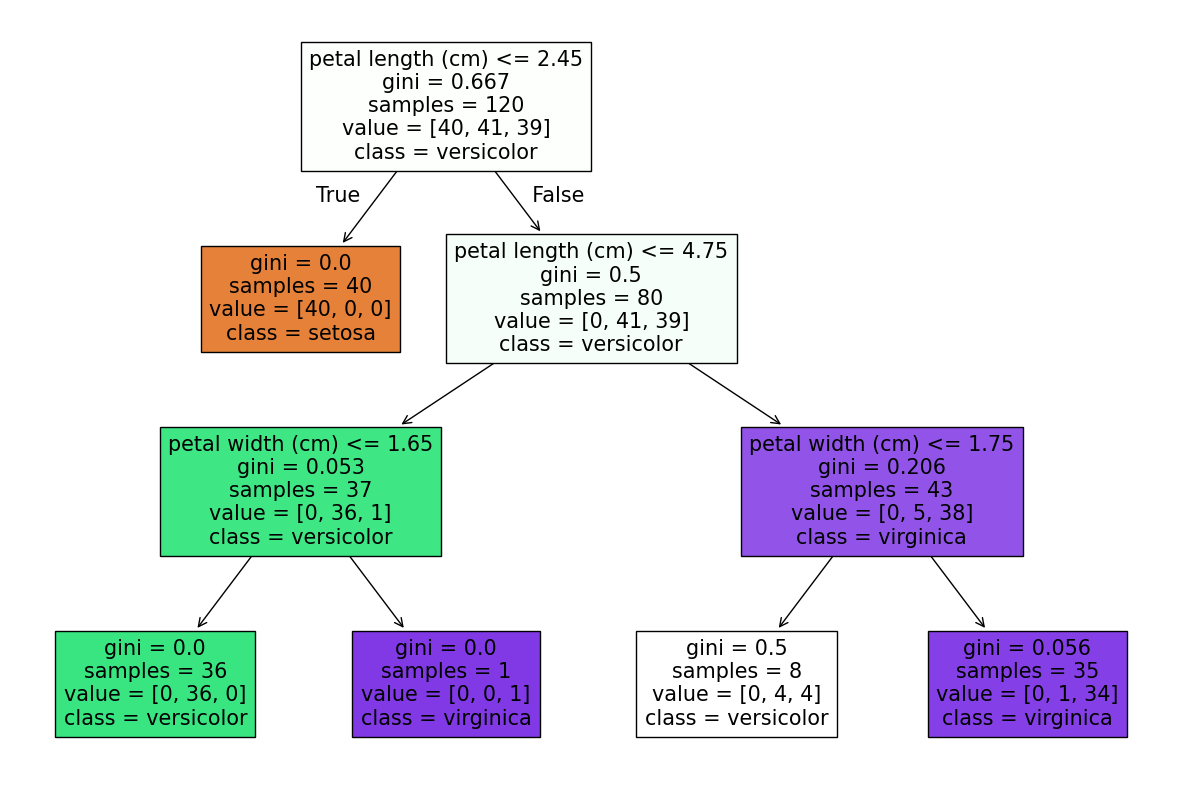

In [12]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

plt.figure(figsize=(15,10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()